# General stuff
## Import required libraries

In [4]:
!pwd

/home/ylnner/Documents/omnet++/omnetpp-6.3.0/projects/florasat_v4_ult_routing/simulations/Test_Individual/results


In [3]:
#df['LSTM_Tx'].unique()
df

,Run,noML_Tx,noML_Ok,LSTM_Tx,LSTM_Ok,TRF_Tx,TRF_Ok,noML_PDR,LSTM_PDR,TRF_PDR,noML_PDR_Efficiency,LSTM_PDR_Efficiency,TRF_PDR_Efficiency
0,1,1243.0,376.0,1199.0,381.0,972.0,382.0,30.249397,31.776480,39.300412,2.433580,2.650249,4.043252
1,2,1256.0,445.0,1212.0,449.0,986.0,436.0,35.429936,37.046205,44.219067,2.820855,3.056618,4.484692
2,3,1258.0,394.0,1216.0,402.0,996.0,386.0,31.319555,33.059211,38.755020,2.489631,2.718685,3.891066
3,4,1264.0,447.0,1217.0,457.0,998.0,444.0,35.363924,37.551356,44.488978,2.797779,3.085567,4.457813
4,5,1268.0,430.0,1222.0,435.0,994.0,424.0,33.911672,35.597381,42.655936,2.674422,2.913043,4.291342
5,6,1264.0,384.0,1212.0,389.0,977.0,375.0,30.379747,32.095710,38.382805,2.403461,2.648161,3.928639
6,7,1263.0,452.0,1213.0,456.0,987.0,428.0,35.787807,37.592745,43.363728,2.833556,3.099155,4.393488
7,8,1254.0,387.0,1207.0,401.0,981.0,377.0,30.861244,33.222867,38.430173,2.461024,2.752516,3.917449
8,9,1271.0,432.0,1223.0,438.0,993.0,414.0,33.988985,35.813573,41.691843,2.674192,2.928338,4.198574
9,10,1246.0,387.0,1203.0,394.0,971.0,382.0,31.059390,32.751455,39.340886,2.492728,2.722482,4.051585


In [9]:
!pwd

/home/ylnner/Documents/omnet++/omnetpp-6.3.0/projects/florasat_v4_ult_routing/simulations/Test_Individual/results


In [ ]:
import pickle

>>> DataFrame calculado y exportado exitosamente a 'florasat_pdr_metrics_report.csv'.
Run          5.500000
noML_PDR    32.835166
LSTM_PDR    34.650698
TRF_PDR     41.062885
dtype: float64


/tmp/ipykernel_1175050/181798165.py:101: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[0].boxplot(box_data_pdr, labels=labels_pdr, patch_artist=True, widths=0.4)
/tmp/ipykernel_1175050/181798165.py:128: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[1].boxplot(box_data_eff, labels=labels_eff, patch_artist=True, widths=0.5)


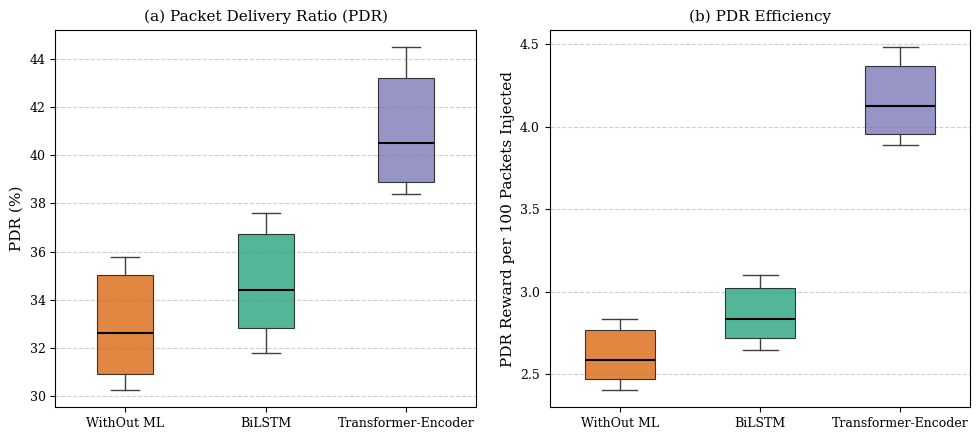

>>> Gráficos vectoriales generados: 'pdr_evolution_per_run.pdf' y 'pdr_stress_analysis_whisker.pdf'.


In [ ]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'grid.linestyle': '--',
    'grid.alpha': 0.6
})



colors = {'noML': '#d95f02', 'LSTM': '#1b9e77', 'TRF': '#7570b3'}


def extract_counts_from_pkl(filename, key_name):
    """
    Read .pkl files that contain the metrics extracted from the simulator.     
    """
    with open(filename, 'rb') as f:
        data = pickle.load(f)
    
    counts = []
    if isinstance(data, list):
        for run_data in data:
            if key_name in run_data:
                counts.append(float(run_data[key_name]))
    elif isinstance(data, dict):        
        if key_name in data:
            val = data[key_name]
            if isinstance(val, (list, np.ndarray)):
                counts = [float(x) for x in val]
            else:
                counts = [float(val)]
            
    return np.array(counts[:10]) 


df = pd.DataFrame({
    'Run': list(range(1, 11)),
    'noML_Tx': extract_counts_from_pkl('noML_run_stats_trx_at_dev.pkl', 'countTrxAtDev'),
    'noML_Ok': extract_counts_from_pkl('noML_run_stats_trx_at_sat.pkl', 'countTrxAtSat'),
    'LSTM_Tx': extract_counts_from_pkl('ML_lstm_run_stats_trx_at_dev.pkl', 'countTrxAtDev'),
    'LSTM_Ok': extract_counts_from_pkl('ML_lstm_run_stats_trx_at_sat.pkl', 'countTrxAtSat'),
    'TRF_Tx':  extract_counts_from_pkl('ML_trf_run_stats_trx_at_dev.pkl', 'countTrxAtDev'),
    'TRF_Ok':  extract_counts_from_pkl('ML_trf_run_stats_trx_at_sat.pkl', 'countTrxAtSat')
})

# =========================================================================
# Process the metrics to calculate PDR and the new efficiency metric
# =========================================================================
# Packet Delivery Ratio (PDR %) estándar
df['noML_PDR'] = (df['noML_Ok'] / df['noML_Tx']) * 100
df['LSTM_PDR'] = (df['LSTM_Ok'] / df['LSTM_Tx']) * 100
df['TRF_PDR']  = (df['TRF_Ok'] / df['TRF_Tx']) * 100


# PDR Efficiency = PDR / (Total_tx / 100) 
df['noML_PDR_Efficiency'] = df['noML_PDR'] / (df['noML_Tx'] / 100)
df['LSTM_PDR_Efficiency'] = df['LSTM_PDR'] / (df['LSTM_Tx'] / 100)
df['TRF_PDR_Efficiency']  = df['TRF_PDR']  / (df['TRF_Tx'] / 100)


# Export metrics to csv for further analysis
df.to_csv('florasat_pdr_metrics_report.csv', index=False)
print(df[['Run', 'noML_PDR', 'LSTM_PDR', 'TRF_PDR']].mean())


# =========================================================================
# Graphs whisker plots PDR
# =========================================================================
fig2, axes = plt.subplots(1, 2, figsize=(10, 4.5))


box_data_pdr = [df['noML_PDR'], df['LSTM_PDR'], df['TRF_PDR']]
labels_pdr = ['WithOut ML', 'BiLSTM', 'Transformer-Encoder']
colors_pdr = [colors['noML'], colors['LSTM'], colors['TRF']]

# Boxplot for PDR
bp2 = axes[0].boxplot(box_data_pdr, labels=labels_pdr, patch_artist=True, widths=0.4)

# Personalize format 
for patch, color in zip(bp2['boxes'], colors_pdr):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
    patch.set_edgecolor('black')
    patch.set_linewidth(0.8)


# Set whiskers and caps and median lines
for element in ['whiskers', 'caps']:
    for line in bp2[element]:
        line.set(color='#404040', linewidth=1)
        
for median in bp2['medians']:
    median.set(color='black', linewidth=1.5)

axes[0].set_title('(a) Packet Delivery Ratio (PDR)')
axes[0].set_ylabel('PDR (%)')
axes[0].grid(True, axis='y')


# Efficiency plot 
box_data_eff = [df['noML_PDR_Efficiency'], df['LSTM_PDR_Efficiency'], df['TRF_PDR_Efficiency']]
labels_eff = ['WithOut ML', 'BiLSTM', 'Transformer-Encoder']

bp1 = axes[1].boxplot(box_data_eff, labels=labels_eff, patch_artist=True, widths=0.5)
for patch, color in zip(bp1['boxes'], [colors['noML'], colors['LSTM'], colors['TRF']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
    patch.set_edgecolor('black')
    patch.set_linewidth(0.8)

for element in ['whiskers', 'caps']:
    for line in bp1[element]:
        line.set(color='#404040', linewidth=1)
for median in bp1['medians']:
    median.set(color='black', linewidth=1.5)

axes[1].set_title('(b) PDR Efficiency')
axes[1].set_ylabel('PDR Reward per 100 Packets Injected')
axes[1].grid(True, axis='y')


plt.tight_layout()
plt.savefig('pdr_and_efficiency.pdf', dpi=300)
plt.show()


plt.close()
print(">>> Gráficos vectoriales generados: 'pdr_evolution_per_run.pdf' y 'pdr_stress_analysis_whisker.pdf'.")